In [1]:
import math
import pandas as pd
import numpy as np
import json

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# READ & CLEAN DATA

- drop testing workerids
- remove duplicates (item getting recorded multiple times by Multitude for some reason)

In [2]:
df = pd.read_csv("./dataRaw/experiment_6323_results.csv")

unnecessary_cols = ["questionid", "filename", "listnumber", "assignmentid", "hitid", "origin", "timestamp", "partid", "imgorder"]
unformatted_df = df.drop(unnecessary_cols, axis=1)

testworkers = ["test", "123", "testFirefox", "testRedirect", "testFinal"]  # add more to this list if there were more test runs
unformatted_df = unformatted_df[~unformatted_df["workerid"].isin(testworkers)]

len(unformatted_df["workerid"].unique())

101

## FORMAT RATING VALUES FROM THE ANSWER COLUMN

In [3]:
df["answer"][2
]

'"{\\"prob1\\":0,\\"prob2\\":0,\\"prob3\\":\\"100\\",\\"probsum\\":100,\\"ratings\\":[{\\"image\\":\\"crunchy.png\\",\\"rating\\":0},{\\"image\\":\\"mushy.png\\",\\"rating\\":0},{\\"image\\":\\"soft.png\\",\\"rating\\":100}],\\"speaker\\":\\"sasha\\",\\"timeTaken\\":13549.199999988079}"'

In [4]:
def format_answer(answer, weak_word, strong_word, antonym):
    """
    returns multiple results.
    whatever data is needed out of the answer, edit and manipulate it in this function
    """
    results = json.loads(json.loads(answer))
    new_dict = dict()
    
    if not results.get("ratings"):
        return None, None, None, None, None, None
    for item in results["ratings"]:
        name = item["image"].replace(".png", "")
        new_dict.update(
            {name: item["rating"]}
        )

    if results["speaker"] in ["frank", "bri"]:
        speakerType = "native"
    else:
        speakerType = "nonnative"
    
    if results["speaker"] in ["bri", "sasha"]:
        speakerGender = "female"
    else:
        speakerGender = "male"

    timeTaken = round(results["timeTaken"]) if results["timeTaken"] else 0
    
    # weak word rating, strong word rating, antonym rating
    return new_dict.get(weak_word), new_dict.get(strong_word), new_dict.get(antonym), speakerType, speakerGender, timeTaken

In [5]:
answers_only_df = unformatted_df.apply(
    lambda x: format_answer(x.answer, x.weak, x.strong, x.antonym), 
    axis=1, 
    result_type="expand",  # this is how you make it into multiple columns
)
answers_only_df.columns=["derivationStrength", "strongRating", "antonymRating", "speakerType", "speakerGender", "timeTaken"]
answers_only_df

,derivationStrength,strongRating,antonymRating,speakerType,speakerGender,timeTaken
1,90.0,10.0,0.0,nonnative,male,17915.0
2,100.0,0.0,0.0,nonnative,female,13549.0
3,35.0,60.0,5.0,native,female,30636.0
4,94.0,6.0,0.0,nonnative,male,19081.0
5,100.0,0.0,0.0,nonnative,male,3904.0
...,...,...,...,...,...,...
3448,100.0,0.0,0.0,nonnative,female,9333.0
3449,100.0,0.0,0.0,native,female,11781.0
3450,100.0,0.0,0.0,nonnative,female,13954.0
3451,100.0,0.0,0.0,native,male,9792.0


## READ WORD FREQ DICT IN

In [6]:
word_freq_dict_df = pd.read_csv("./dataRaw/wordFreqDict.csv")
word_freq_dict_df.head()

word_freq_dict_df[word_freq_dict_df['Frequency'].isin(["x"])]

,Word,Rank,Frequency


## DATAFRAME CLEAN UP

1. concat the formatted answers dataframe back into the original and drop the old answers column that contained ALL the audio information
2. rename column names to be what is required in the models
3. trialid - each participant, set to 1 - 32 instead of the unique IDs each trial got
4. drop rows with NAs

In [7]:
answers_df = pd.concat([unformatted_df, answers_only_df], axis=1)
answers_df = answers_df.drop(["answer"], axis=1)

answers_df = answers_df.rename(columns={
    "workerid": "participantId",
    "itemid": "itemId",
    "type": "itemType",
    "id": "trialid"
})

# create a minimum column based on the participantId group by, then subtract that from all the trial ids 
# add 1 so we have range 1 - 32 on the trial ids. 
answers_df["trialidmin"] = answers_df.groupby("participantId")["trialid"].transform("min")
answers_df["newtrialid"] = (answers_df["trialid"] - answers_df["trialidmin"] + 1)
answers_df = answers_df.drop(["trialid", "trialidmin"], axis=1)
answers_df = answers_df.rename(columns={
    "newtrialid": "trialid"
})

# there are three participants whose submission went through twice at the time or within 2 seconds of each other
# 1) for one participant - one submission was all NaNs and the other had proper values in it
#    so we just drop the NaN values and take the submission with values in it
# 2) for two participants - same answer values for two submissions, we'll take the first set of submissions
answers_df = answers_df.dropna(subset=["derivationStrength"])
drop_rows = answers_df[answers_df["trialid"] > 32].index
answers_df.drop(drop_rows, inplace=True)

answers_df.shape

(3232, 15)

# FILTER - EXCLUSION CRITERIA

### Picture Rating Control Trials

In [8]:
# filter out rating scores
#    - if avg. rating across all unambiguous trials were < 80%
umambiguous_trials = answers_df[answers_df["itemType"] == "unambiguous"]
picrating_filtered_participants = list(
    pd.unique(
        umambiguous_trials.groupby("participantId").filter(
            lambda x: x["derivationStrength"].mean() < 80
        )["participantId"]
    )
)
picrating_filtered_participants

[]

### Picture Rating Technical Problems

In [9]:
# make sure there are not any NaN values in derivationStrength
countNaN = answers_df["derivationStrength"].isnull().groupby(
    answers_df["participantId"]
).sum().astype(int).reset_index(name="countNaN")
NaNTrials = list(countNaN[countNaN["countNaN"] > 1]["participantId"].unique())

# make sure there are no participants who have weird number of submissions
not32trials = list(answers_df.groupby("participantId").filter(
    lambda x: x["trialid"].count() != 32
)["participantId"].unique())

technical_prob_filtered_participants = NaNTrials + not32trials
technical_prob_filtered_participants

[]

## Audio Filtered Participants

After transcribing the audio for the two practice perspective taking trials, any that did not choose the target word will be excluded.

Anyone who did not provide a response that is indicative of understanding the task in the final critical audio explanation will be excluded.

In [10]:
audio_filtered_participants = [
    # Missed any of the perspective taking trials (from the already filtered participants)
    "69f7b962446b32b08d58a1df",
    "69e816058da70eddb5dbc3e1",
    "69f6484996726366cacd162c",
    "69efe0b03221edd72686c185",
    "69ed15278090fe4438301d5c",
    "6a0a0fd9f370053c3505dc0f",
    "66da162f5538535e93490441",
    "69d5632f4815bcc4cb7242bf",
    "69cec122e3cb56c2e7000c6b",
    "6a012d3c523e7311f4e55f61",
    "69a0734d1d433d3694c8438f",
    "69e957ad6c65e153a1c65ae2",

    # from the final run
    "6980dfb784202dcf9736910f",
    "69d5c4d748bcaf8026c80573",
    "6a15dfdb880253e5b6b917f3",
    "697a495862ac67423e8418b8",
]

## ToM Filtered Participants

These participants are identified after running the `nathan.R` script:
- technical problems (anything over 10% of responses missing): grab from `/dataOutput/ToM/failed_questions.csv` file
- control accuracy < 80: is in the output of the R script

In [11]:
nathan4u_filtered_participants = [
    # control accuracy < 50%
    "6978d830c5d415696508430d",
    "69c093d33989aa791c4e8b2d",
    "6a00dbcc626a780a8e5c07a4", 
    "6a177f7ec67996448d9c7d41",
    "6a1f0ef7a64d44c972d3a5f7",
    "6a232745f21e165e2b54ed58",
    "6a2482e9af72b55296872b0d"
]

nathan4u_technical_issues = [
    # technical issues: 50+ unanswered
    "69c093d33989aa791c4e8b2d", 
    "6a2482e9af72b55296872b0d",
    "6a1f0ef7a64d44c972d3a5f7",
    "6a00dbcc626a780a8e5c07a4",
    "6a177f7ec67996448d9c7d41",
    "6a232745f21e165e2b54ed58",
]

## Total Filtered Participants

In [12]:
all_filtered_participants = list(set(
    picrating_filtered_participants + 
    nathan4u_technical_issues +
    nathan4u_filtered_participants + 
    audio_filtered_participants + 
    technical_prob_filtered_participants
))

print("total number of filtered participants: ", len(all_filtered_participants))

total number of filtered participants:  23


In [13]:
answers_df = answers_df[~answers_df["participantId"].isin(all_filtered_participants)]

In [14]:
answers_df["participantId"].unique()

<StringArray>
['62c5f85ccf34c8d9c0650f6e', '65465c5bc5a014ec683d55cf',
 '661c09a749790db73f8faba5', '66315563a848526fcfa7555b',
 '66577b950cf252021eff76f8', '665795d82a087799023aaf0e',
 '676956116c1a3416bf7b2afe', '695ea002344d7ca1605c747a',
 '6965bd850ce22095dd7a84ca', '69864a705614c15728117b35',
 '6987875a0a8fa6ed9ef00726', '699b610e2ba4bade6f39121b',
 '699cebf39bc275a312ffd51c', '699d45af20adaa6e1e89aa5a',
 '699e3cc79b0d3d96b469ca49', '69a6eb2bc679065ed1cecc51',
 '69a8cff018bead25e4a5d848', '69b19e44edf4d70aee145c16',
 '69b3193cce0978ad6db9fe7c', '69b5c6bdbcf55371066f5e73',
 '69ba37faee13f176e7635323', '69bdf2afe629d42bfc47997f',
 '69c1256faa88d6296c98d745', '69c2f0033339865c279814ca',
 '69c6ec3a92185003cf70ded5', '69cc1fac2b52b1c4dd21cc7d',
 '69d2a8765e19038ab2fc0f56', '69daf476f6bc0d990581aca6',
 '69dbf4749918745fc7d8e820', '69dc76f0a77a620367d666ec',
 '69dfe696c433039b7add8013', '69e599577d00fb31c54fb004',
 '69f0438cc141b27ed949788e', '69f3d4f3fb7630947c56f1eb',
 '69f674db81cb466

# MERGE DFs TOGETHER

## all the word information back into the response dataframe

In [15]:
# get the weak word info
final_df = answers_df.merge(word_freq_dict_df, left_on="weak", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "weakRank",
    "Frequency": "weakFreq",
})

# get the strong word info
final_df = final_df.merge(word_freq_dict_df, left_on="strong", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "strongRank",
    "Frequency": "strongFreq",
})

# get the antonym word info
final_df = final_df.merge(word_freq_dict_df, left_on="antonym", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "antonymRank",
    "Frequency": "antonymFreq",
})

# create freq ratios
cols = ["weakFreq", "strongFreq", "antonymFreq", "weakRank", "strongRank", "antonymRank"]
final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce', axis=1)
final_df["freqRatio"] = final_df["weakFreq"] / final_df["strongFreq"]
# if freq ratio is nan, fill it with 2
final_df["freqRatio"] = final_df["freqRatio"].apply(lambda x: math.log10(x))
final_df.head(6)

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,...,speakerGender,timeTaken,trialid,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,...,male,17915.0,21,1381,27970,18362,478,14284,834,1.767265
1,65465c5bc5a014ec683d55cf,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,female,13549.0,17,1381,27970,18362,478,14284,834,1.767265
2,661c09a749790db73f8faba5,1,critical,soft,mushy,crunchy,panicked,introspective,35.0,60.0,...,female,30636.0,17,1381,27970,18362,478,14284,834,1.767265
3,66315563a848526fcfa7555b,1,critical,soft,mushy,crunchy,panicked,introspective,94.0,6.0,...,male,19081.0,9,1381,27970,18362,478,14284,834,1.767265
4,66577b950cf252021eff76f8,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,male,3904.0,19,1381,27970,18362,478,14284,834,1.767265
5,665795d82a087799023aaf0e,1,critical,soft,mushy,crunchy,panicked,introspective,0.0,100.0,...,female,14236.0,13,1381,27970,18362,478,14284,834,1.767265


In [16]:
final_df.shape

(2496, 22)

## read and merge the ToM scores in

In [17]:
tom_scores_df = pd.read_csv("./dataOutput/ToM/nathan_scores.csv")[["workerid", "nathan_score_full"]]
tom_scores_df = tom_scores_df[~tom_scores_df["workerid"].isin(all_filtered_participants)]

final_tom_df = final_df.merge(tom_scores_df, left_on="participantId", right_on="workerid")

final_tom_df

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,...,trialid,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio,workerid,nathan_score_full
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,...,21,1381,27970,18362,478,14284,834,1.767265,62c5f85ccf34c8d9c0650f6e,0.865385
1,65465c5bc5a014ec683d55cf,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,17,1381,27970,18362,478,14284,834,1.767265,65465c5bc5a014ec683d55cf,0.711538
2,661c09a749790db73f8faba5,1,critical,soft,mushy,crunchy,panicked,introspective,35.0,60.0,...,17,1381,27970,18362,478,14284,834,1.767265,661c09a749790db73f8faba5,0.807692
3,66315563a848526fcfa7555b,1,critical,soft,mushy,crunchy,panicked,introspective,94.0,6.0,...,9,1381,27970,18362,478,14284,834,1.767265,66315563a848526fcfa7555b,0.788462
4,665795d82a087799023aaf0e,1,critical,soft,mushy,crunchy,panicked,introspective,0.0,100.0,...,13,1381,27970,18362,478,14284,834,1.767265,665795d82a087799023aaf0e,0.884615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,6a1de36b3f5c6160ff6bf6a4,32,unambiguous,odd,even,prime,passive,silly,100.0,0.0,...,30,2762,11849,11812,1124,1677,22075,1.022915,6a1de36b3f5c6160ff6bf6a4,0.884615
2428,6a1f832105dd8c89b5e930ad,32,unambiguous,odd,even,prime,passive,silly,100.0,0.0,...,24,2762,11849,11812,1124,1677,22075,1.022915,6a1f832105dd8c89b5e930ad,0.788462
2429,6a2222ff6e1036656b0d5d08,32,unambiguous,odd,even,prime,passive,silly,100.0,0.0,...,16,2762,11849,11812,1124,1677,22075,1.022915,6a2222ff6e1036656b0d5d08,0.788462
2430,6a2589e7b0645f2f7f1cc52c,32,unambiguous,odd,even,prime,passive,silly,100.0,0.0,...,11,2762,11849,11812,1124,1677,22075,1.022915,6a2589e7b0645f2f7f1cc52c,0.711538


In [18]:
# participants who finished the picture rating task but did NOT finish the ToM task
# automatically filtered out when we did the merge 
[a for a in tom_scores_df["workerid"].unique() if a not in answers_df["participantId"].unique()] + [a for a in answers_df["participantId"].unique() if a not in tom_scores_df["workerid"].unique()]

['66577b950cf252021eff76f8', '6a061f0e3198b87bb067f8ee']

# FINAL OUTPUT

### Basic Formatted Results

In [19]:
final_remove_cols = ["weakRank", "strongRank", "antonymRank", "weakFreq", "strongFreq", "antonymFreq"]
final_tom_df = final_tom_df.drop(final_remove_cols, axis=1)
final_tom_df.to_csv("./dataOutput/formatted_results.csv")

### Group By For RSA Modeling

In [22]:
rsa_model_rollup = ["itemId",  "itemType", "speakerType",]
rsa_rollup = final_df.groupby(rsa_model_rollup)

rollup_results = rsa_rollup[["derivationStrength", "strongRating"]].mean().reset_index()
rollup_results.to_csv("./dataOutput/derivationByItemSpeaker.csv")

# Demographics

In [19]:
demographics = pd.read_csv("./dataRaw/demographics.csv")
final_part_demo = demographics[demographics["Participant id"].isin(final_tom_df["participantId"])]

final_part_demo['Age'] = pd.to_numeric(final_part_demo['Age'], downcast='integer', errors='coerce')

print("age mean: ", final_part_demo["Age"].mean())
print("age std: ", final_part_demo["Age"].std())
print("age range: ", final_part_demo["Age"].min(), final_part_demo["Age"].max())

age mean:  37.93421052631579
age std:  11.813365906255832
age range:  19 66


In [20]:
final_part_demo.groupby("Sex")["Sex"].count()

Sex
Female    57
Male      19
Name: Sex, dtype: int64

# DESCRIPTIVE CHARTS

In [41]:
effect_only = rollup_results[rollup_results["derivationStrength"] > rollup_results["strongRating"]]
effect_only = effect_only[effect_only["itemType"] == "critical"]

effect_only.groupby("speakerType").count()
# 2 items no effect for native, 4 no effect for nonnative 

,itemId,itemType,derivationStrength,strongRating
speakerType,,,,
native,14,14,14,14
nonnative,12,12,12,12


### General Rating Native vs Nonnative

In [131]:
crits = final_tom_df[final_tom_df["itemType"] == "critical"]
native = crits[crits["speakerType"] == "native"]
nonnative = crits[crits["speakerType"] != "native"]

native["derivationStrength"].sem(), nonnative["derivationStrength"].sem()

(np.float64(1.6875117403075188), np.float64(1.673299183875749))

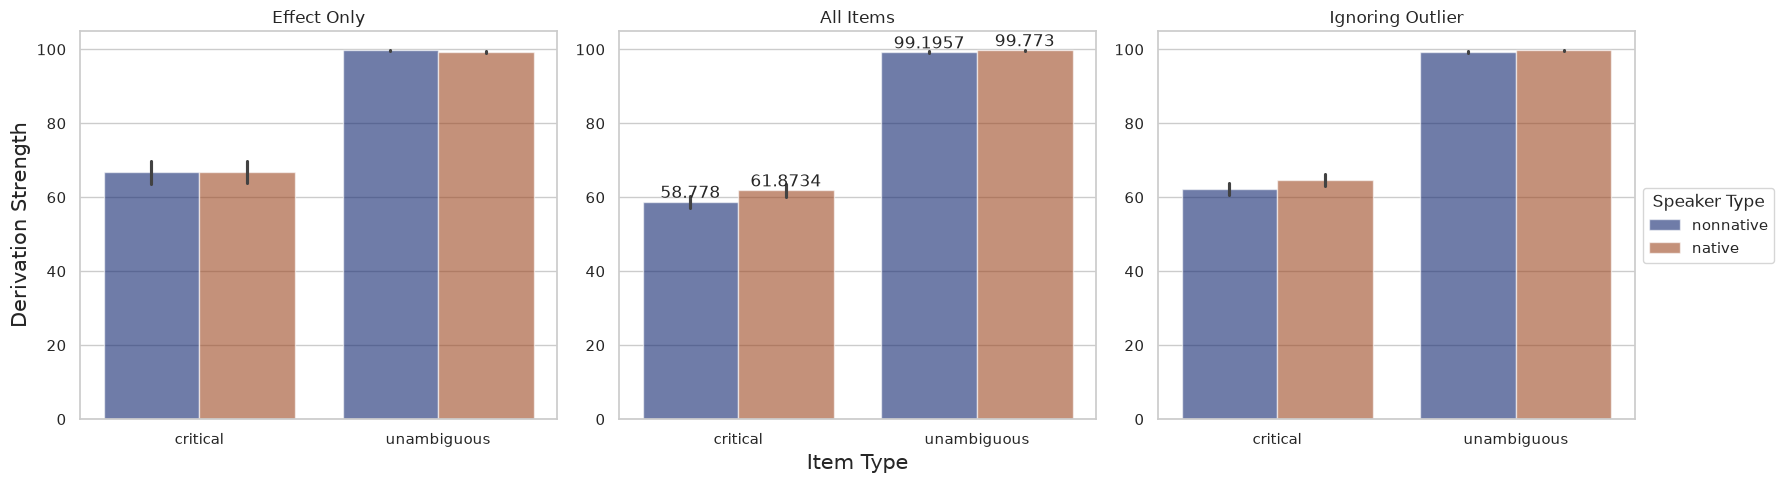

In [123]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=effects_only,
    x="itemType", y="derivationStrength",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[0],
    legend=False,
)
axs[0].set_title('Effect Only')

g = sns.barplot(
    data=final_tom_df, 
    x="itemType", y="derivationStrength",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[1],
    legend=False,
)
axs[1].set_title('All Items')

for container in g.containers:
    g.bar_label(container)

ignore_13 = final_df[final_df["itemId"] != 13]
sns.barplot(
    data=ignore_13,
    x="itemType", y="derivationStrength",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[2]
)
axs[2].set_title('Ignoring Outlier')

axs[0].set_ylabel("Derivation Strength", fontsize=15)
axs[1].set_xlabel("Item Type", fontsize=15)
axs[1].set(ylabel=None)
axs[2].set(ylabel=None)
axs[0].set(xlabel=None)
axs[2].set(xlabel=None)
axs[2].legend(
    loc="center left", bbox_to_anchor=(1, 0.5), title="Speaker Type"
)

plt.tight_layout()

In [ ]:
fig, axs = plt.subplots(1, 3)

effects_only = rollup_results[rollup_results["derivationStrength"] > rollup_results["strongRating"]]
sns.catplot(
    data=effects_only, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[0]
)
axs[0].set_title('AVG Derivation Strength (Native vs Nonnative) - Effect Only')

sns.catplot(
    data=final_tom_df, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[1]
)
axs[1].set_title('AVG Derivation Strength (Native vs Nonnative)')

ignore_13 = final_df[final_df["itemId"] != 13]
sns.catplot(
    data=ignore_13, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6, ax=axs[2]
)
axs[2].set_title('AVG Derivation Strength (Native vs Nonnative)')

plt.subplots_adjust(wspace=5.0)
plt.tight_layout()
plt.show()

In [122]:
sns.set(style="whitegrid")

g = sns.barplot(
    data=final_tom_df, 
    x="itemType", y="derivationStrength",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8
)
g.set_ylabel("Derivation Strength")
g.set_xlabel("Item Type")

graph_rollup_cols = ["itemType", "speakerType",]
graph_rollup = final_tom_df.groupby(graph_rollup_cols)
graph_rollup = graph_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')
graph_rollup

plt.savefig(f"./dataPlots/allTrials.png")
plt.clf()

<Figure size 640x480 with 0 Axes>

,itemType,speakerType,avgDerivationStrength
0,critical,native,64.646758
1,critical,nonnative,62.289384
2,unambiguous,native,99.778846
3,unambiguous,nonnative,99.216346


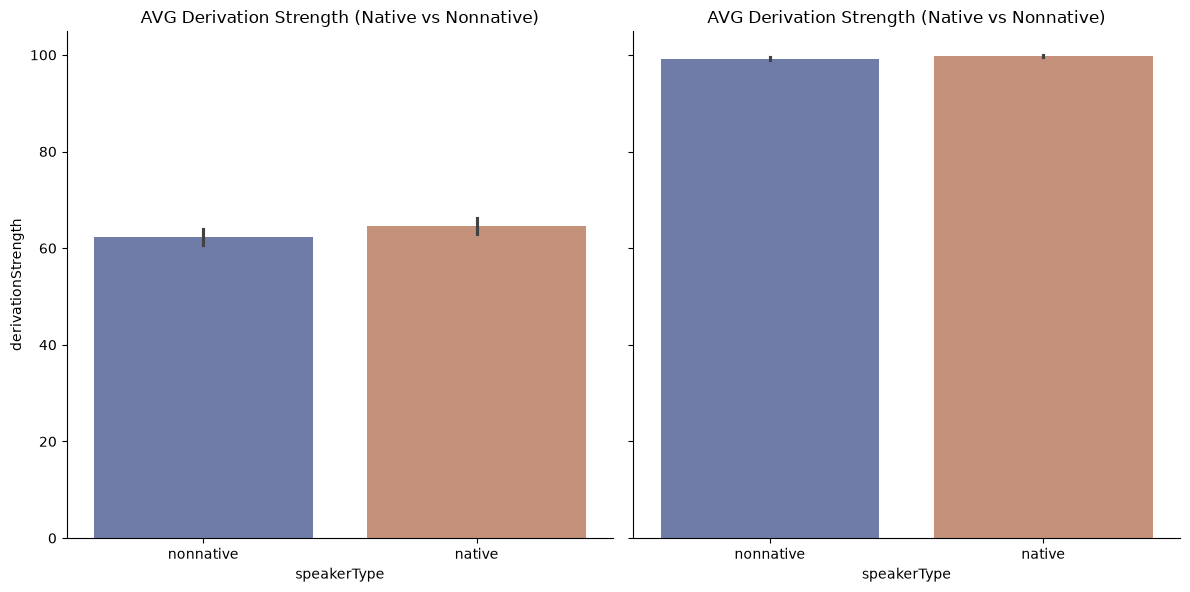

In [185]:
ignore_13 = final_df[final_df["itemId"] != 13]

graph_without_13 = sns.catplot(
    data=ignore_13, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6,
).set(title='AVG Derivation Strength (Native vs Nonnative)')

graph_rollup_cols = ["itemType", "speakerType",]
graph_rollup = ignore_13.groupby(graph_rollup_cols)
graph_rollup = graph_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')
graph_rollup

In [134]:
sns.set(style="whitegrid")
sns.set(font_scale=2)

crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]
crit_only["scale"] = "<" + crit_only["weak"] + ", " + crit_only["strong"] + ">"

unambiguous = final_tom_df[final_tom_df["itemType"] == "unambiguous"]

g = sns.catplot(
    data=crit_only, kind="bar",
    y="derivationStrength", height=6, col="scale",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8, col_wrap=4,
)

plt.savefig(f"./dataPlots/allCrits.png")
plt.clf()

g = sns.catplot(
    data=unambiguous, kind="bar",
    y="derivationStrength", height=6, col="itemId",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8, col_wrap=4,
)

plt.savefig(f"./dataPlots/allUnambiguous.png")
plt.clf()

<Figure size 2666x2400 with 0 Axes>

<Figure size 2666x2400 with 0 Axes>

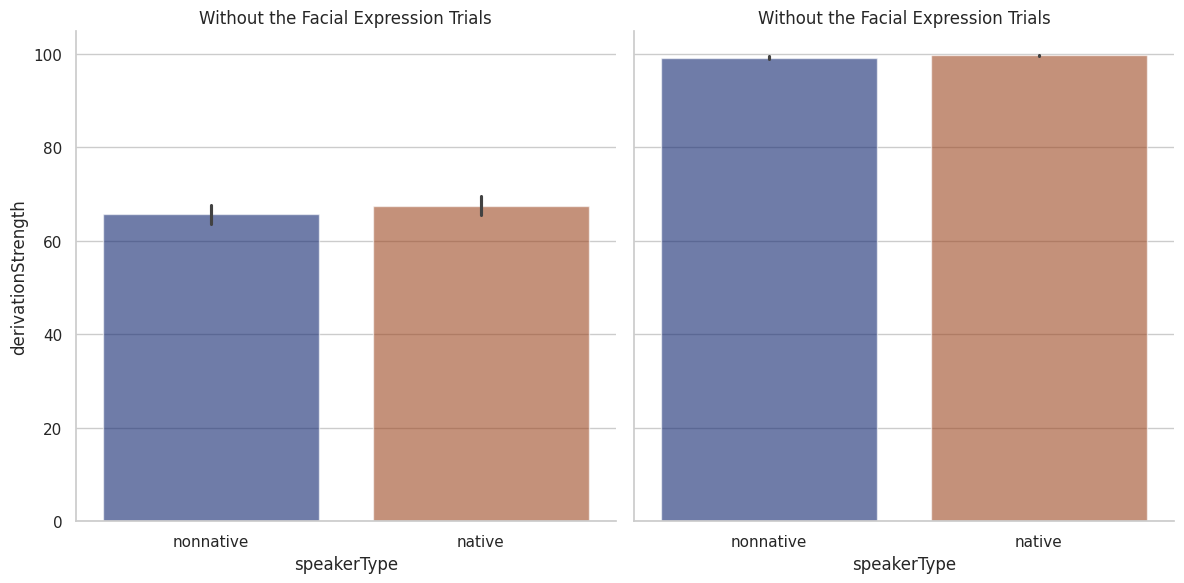

In [22]:
faceless = sns.catplot(
    data=removed_faces, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6,
).set(title='Without the Facial Expression Trials')

## Time Taken on Trials

In [23]:
time_taken_rollup_cols = ["speakerType",]
time_rollup = final_tom_df.groupby(time_taken_rollup_cols)

time_rollup["timeTaken"].mean()

speakerType
native       13900.537007
nonnative    14605.167763
Name: timeTaken, dtype: float64

In [74]:
final_tom_df.columns

Index(['participantId', 'itemId', 'itemType', 'weak', 'strong', 'antonym',
       'lowfreq1', 'lowfreq2', 'derivationStrength', 'strongRating',
       'antonymRating', 'speakerType', 'speakerGender', 'timeTaken', 'trialid',
       'weakRank', 'weakFreq', 'strongRank', 'strongFreq', 'antonymRank',
       'antonymFreq', 'freqRatio', 'workerid', 'nathan_score_full'],
      dtype='str')

In [85]:
sns.set(style="whitegrid")
sns.set(font_scale=2)

crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]
crit_only["scale"] = "<" + crit_only["weak"] + ", " + crit_only["strong"] + ">"

unambiguous = final_tom_df[final_tom_df["itemType"] == "unambiguous"]

g = sns.catplot(
    data=crit_only, kind="bar",
    y="timeTaken", height=6, col="scale",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8, col_wrap=4,
)

plt.savefig(f"./dataPlots/timeTakenCritical.png")
plt.clf()


g = sns.catplot(
    data=unambiguous, kind="bar",
    y="timeTaken", height=6, col="itemId",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8, col_wrap=4,
)

plt.savefig(f"./dataPlots/timeTakenUnambiguous.png")
plt.clf()

<Figure size 2666x2400 with 0 Axes>

<Figure size 2666x2400 with 0 Axes>

### Individual Rating Differences Native minus Nonnative

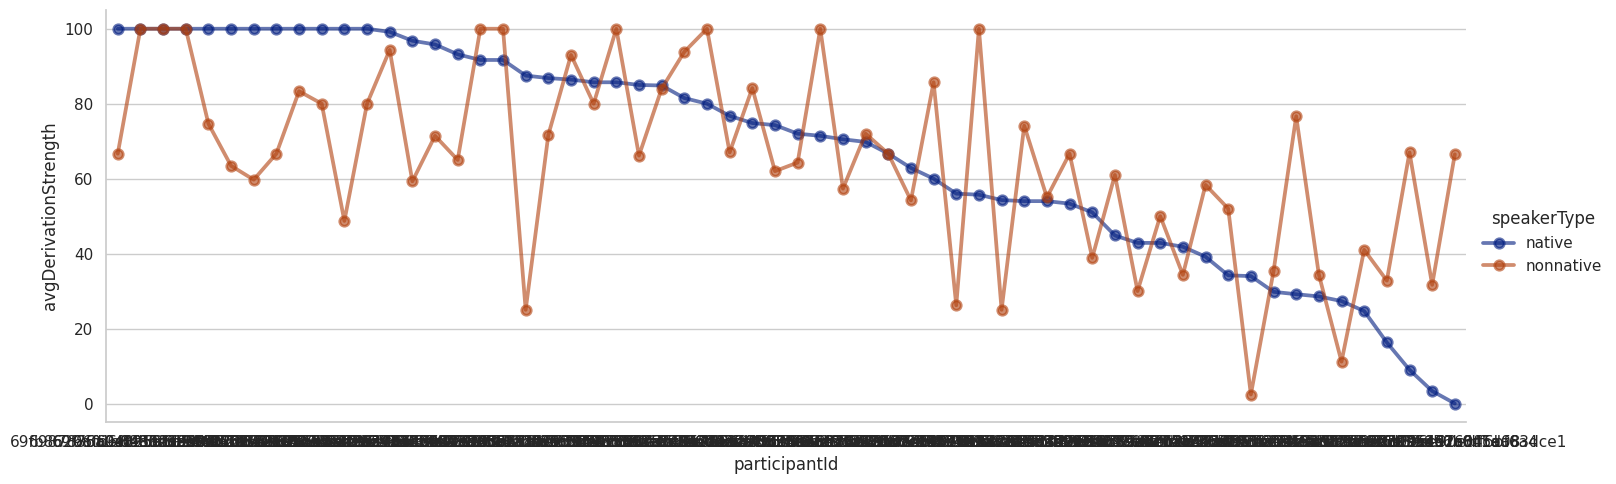

In [23]:
sorted_indiv_derivation_scores = crit_only.groupby(["participantId", "speakerType"])["derivationStrength"].mean().reset_index(
    name='avgDerivationStrength'
)

crits = sorted_indiv_derivation_scores[
    sorted_indiv_derivation_scores["speakerType"] == "native"
].sort_values(["avgDerivationStrength"], ascending=False).rename(columns={"avgDerivationStrength": "sortkey"})

sorted_indiv_derivation_scores = sorted_indiv_derivation_scores.merge(
    crits[["participantId", "sortkey"]], on="participantId"
).sort_values(["sortkey"], ascending=False)

# sorted_indiv_derivation_scores["range"] = range(1, len(sorted_indiv_derivation_scores) + 1)

sns.catplot(
    data=sorted_indiv_derivation_scores, kind="point",
    x="participantId", y="avgDerivationStrength",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6, height=5, aspect=3
)

# TODO:
# plot the difference between the two lines and order it
# axis: diff in rating for nonnative - native x ToM score

# exploratory: look at group of people who do find effect

In [98]:
crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]
crit_only.head()

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,...,trialid,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio,workerid,nathan_score_full
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,...,21,1381,27970,18362,478,14284,834,1.767265,62c5f85ccf34c8d9c0650f6e,0.865385
1,65465c5bc5a014ec683d55cf,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,17,1381,27970,18362,478,14284,834,1.767265,65465c5bc5a014ec683d55cf,0.711538
2,661c09a749790db73f8faba5,1,critical,soft,mushy,crunchy,panicked,introspective,35.0,60.0,...,17,1381,27970,18362,478,14284,834,1.767265,661c09a749790db73f8faba5,0.807692
3,66315563a848526fcfa7555b,1,critical,soft,mushy,crunchy,panicked,introspective,94.0,6.0,...,9,1381,27970,18362,478,14284,834,1.767265,66315563a848526fcfa7555b,0.788462
4,665795d82a087799023aaf0e,1,critical,soft,mushy,crunchy,panicked,introspective,0.0,100.0,...,13,1381,27970,18362,478,14284,834,1.767265,665795d82a087799023aaf0e,0.884615


41 of the 76 participants (53.9%) had a larger mean derivation for 
native speakers than nonnative speakers.
    


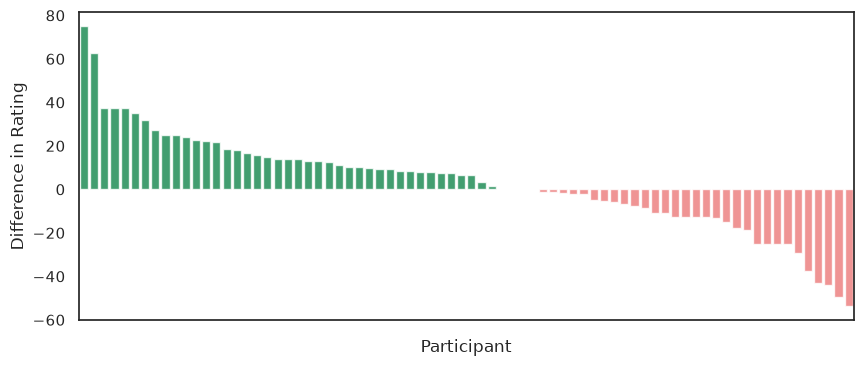

In [115]:
sns.set(font_scale=1)
sns.set_theme(style='white')

native_derivation = crit_only[
    crit_only["speakerType"] == "native"
].groupby(["participantId"])["derivationStrength"].mean()

nonnative_derivation = crit_only[
    crit_only["speakerType"] != "native"
].groupby(["participantId"])["derivationStrength"].mean()

partDerivDiff = pd.DataFrame(native_derivation).merge(
    pd.DataFrame(nonnative_derivation), 
    on="participantId", 
    suffixes=('Native', 'NonNative')
).reset_index()

partDerivDiff["natNonNatDiff"] = partDerivDiff["derivationStrengthNative"] - partDerivDiff["derivationStrengthNonNative"]
partDerivDiff.sort_values(["natNonNatDiff"], ascending=False, inplace=True)
partDerivDiff.insert(0, 'newId', range(1, 1 + len(partDerivDiff)))
partDerivDiff["Positive"] = partDerivDiff["natNonNatDiff"] > 0

palette = {True: "#00994C", False: "#FF6666"}

plt.figure(figsize=(10,4))

g = sns.barplot(
    data=partDerivDiff,
    x="newId", y="natNonNatDiff", hue="Positive",
    alpha=.8, palette=palette, legend=False
)

g.grid(False)

g.set(
    xticklabels=[],
    xlabel="Participant",
    ylabel="Difference in Rating"
)

fig = g.get_figure()
fig.savefig("dataPlots/nativeMinusNonnative.png") 

over_0 = partDerivDiff[partDerivDiff["natNonNatDiff"] > 0]["participantId"]
total_parts = len(partDerivDiff)
print(
    f"""{len(over_0)} of the {total_parts} participants ({len(over_0)*100/total_parts:.1f}%) had a larger mean derivation for 
native speakers than nonnative speakers.
    """
)

In [121]:
partDerivDiff[partDerivDiff["Positive"] == True]["participantId"]

<StringArray>
['69f0438cc141b27ed949788e', '69cc1fac2b52b1c4dd21cc7d',
 '6a0f1056788a67850f057de4', '69fb86296fb6f0919bf31075',
 '6a1cb95bf369926ac77ea9e5', '6a1b544246f12219f033d3c3',
 '69b5c6bdbcf55371066f5e73', '69fb3314a5e95601464d1fea',
 '676956116c1a3416bf7b2afe', '6a2589e7b0645f2f7f1cc52c',
 '6a1f832105dd8c89b5e930ad', '6a0b756dd47d16a4c82f5589',
 '6a07687bad5809e8867bdffb', '69dfe696c433039b7add8013',
 '699cebf39bc275a312ffd51c', '6a05131f0ad03d07dd77178e',
 '69b19e44edf4d70aee145c16', '69dc76f0a77a620367d666ec',
 '69f3d4f3fb7630947c56f1eb', '69fcc8642de981c893eb6958',
 '6a00b0ca46e3f2822d0349b6', '69f86a04fe802de5002bb70b',
 '6a18b37c0157d881234ed29f', '6a1a3e6d47ea4b557072cc4d',
 '69c2f0033339865c279814ca', '69dbf4749918745fc7d8e820',
 '6a14c736578656591db6ea31', '699d45af20adaa6e1e89aa5a',
 '69daf476f6bc0d990581aca6', '69e599577d00fb31c54fb004',
 '6a0b7296246f70341f078e55', '6a14434573bcee3f17b7f762',
 '69c1256faa88d6296c98d745', '69fce9e45d612732dd1ae4e2',
 '69bdf2afe629d42

51

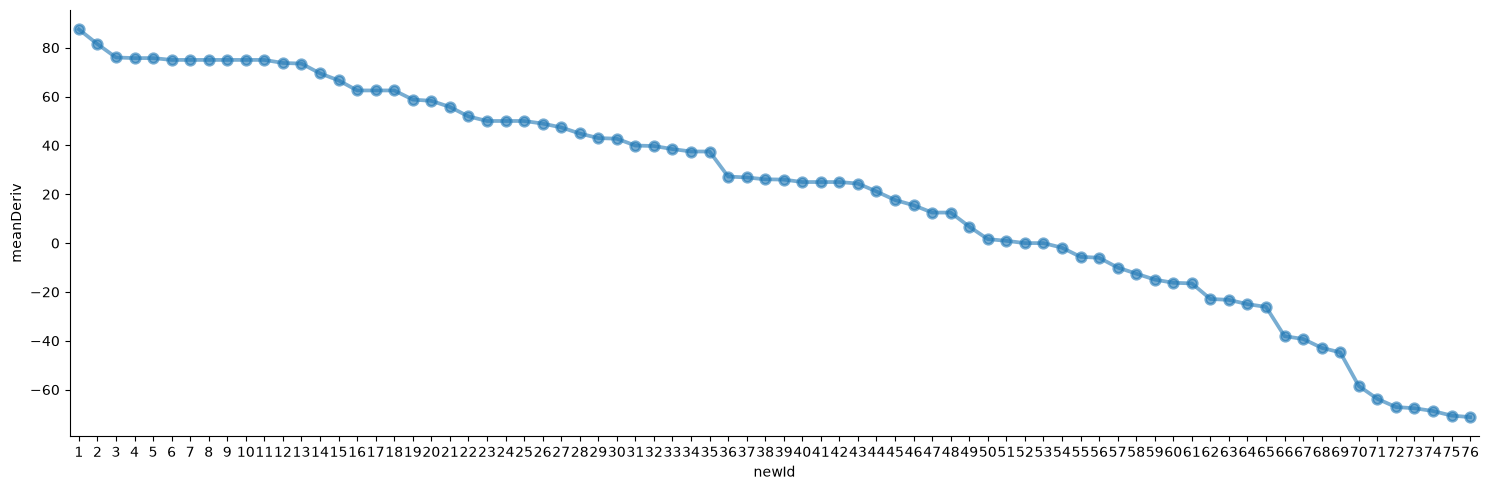

In [221]:
crit_only["derivationDiff"] = crit_only["derivationStrength"] - crit_only["strongRating"]
crit_only["meanDeriv"] = crit_only.groupby(["participantId"])["derivationDiff"].transform("mean")
avg_gap = crit_only[["participantId", "meanDeriv"]]
avg_gap = avg_gap.drop_duplicates().sort_values(by=["meanDeriv"], ascending=False)
avg_gap.insert(0, 'newId', range(1, 1 + len(avg_gap)))

sns.catplot(data=avg_gap, kind="point", x="newId", y="meanDeriv", alpha=.6, height=5, aspect=3)

print(
    f"{len(avg_gap[avg_gap["meanDeriv"] > 0]["participantId"])} of the {len(avg_gap)} participants had a larger mean derivation for n

In [ ]:
sorted_indiv_derivation_scores = crit_only.groupby(["participantId", "speakerType"])["derivationStrength"].mean().reset_index(
    name='avgDerivationStrength'
)

crits = sorted_indiv_derivation_scores[
    sorted_indiv_derivation_scores["speakerType"] == "native"
].sort_values(["avgDerivationStrength"], ascending=False).rename(columns={"avgDerivationStrength": "sortkey"})

sorted_indiv_derivation_scores = sorted_indiv_derivation_scores.merge(
    crits[["participantId", "sortkey"]], on="participantId"
).sort_values(["sortkey"], ascending=False)

# sorted_indiv_derivation_scores["range"] = range(1, len(sorted_indiv_derivation_scores) + 1)

sns.catplot(
    data=sorted_indiv_derivation_scores, kind="point",
    x="participantId", y="avgDerivationStrength",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6, height=5, aspect=3
)

In [144]:
partDerivDiff

,newId,participantId,derivationStrengthNative,derivationStrengthNonNative,natNonNatDiff,Positive
31,1,69f0438cc141b27ed949788e,87.500,12.50,75.000,True
24,2,69cc1fac2b52b1c4dd21cc7d,87.500,25.00,62.500,True
55,3,6a0f1056788a67850f057de4,87.500,50.00,37.500,True
37,4,69fb86296fb6f0919bf31075,100.000,62.50,37.500,True
70,5,6a1cb95bf369926ac77ea9e5,100.000,62.50,37.500,True
...,...,...,...,...,...,...
15,72,69a8cff018bead25e4a5d848,62.500,100.00,-37.500,False
64,73,6a15d5fb80117206e7200cf7,40.625,83.75,-43.125,False
73,74,6a2222ff6e1036656b0d5d08,23.000,67.00,-44.000,False
0,75,62c5f85ccf34c8d9c0650f6e,24.375,73.75,-49.375,False


In [180]:

indivs_nativ = indivs_means[
    indivs_means["speakerType"] == "native"
]
indivs_nonnativ = indivs_means[
    indivs_means["speakerType"] != "native"
]

indivs_merged = pd.DataFrame(indivs_nativ).merge(
    pd.DataFrame(indivs_nonnativ), 
    on=["participantId", "itemType"], 
    suffixes=('Native', 'NonNative')
).reset_index()

indivs_merged["natNonNatDiff"] = indivs_merged["derivationStrengthNative"] - indivs_merged["derivationStrengthNonNative"]
indivs_merged[indivs_merged["itemType"] == "critical"]

,index,participantId,itemType,speakerTypeNative,derivationStrengthNative,nathan_score_fullNative,speakerTypeNonNative,derivationStrengthNonNative,nathan_score_fullNonNative,natNonNatDiff
0,0,62c5f85ccf34c8d9c0650f6e,critical,native,24.375,0.865385,nonnative,73.750,0.865385,-49.375
2,2,65465c5bc5a014ec683d55cf,critical,native,56.250,0.711538,nonnative,68.750,0.711538,-12.500
4,4,661c09a749790db73f8faba5,critical,native,41.875,0.807692,nonnative,57.000,0.807692,-15.125
6,6,66315563a848526fcfa7555b,critical,native,73.625,0.788462,nonnative,84.625,0.788462,-11.000
8,8,665795d82a087799023aaf0e,critical,native,12.500,0.884615,nonnative,12.500,0.884615,0.000
...,...,...,...,...,...,...,...,...,...,...
142,142,6a1de36b3f5c6160ff6bf6a4,critical,native,5.000,0.884615,nonnative,23.750,0.884615,-18.750
144,144,6a1f832105dd8c89b5e930ad,critical,native,100.000,0.788462,nonnative,75.750,0.788462,24.250
146,146,6a2222ff6e1036656b0d5d08,critical,native,23.000,0.788462,nonnative,67.000,0.788462,-44.000
148,148,6a2589e7b0645f2f7f1cc52c,critical,native,87.500,0.711538,nonnative,62.500,0.711538,25.000


### TOM vs Derivation Strength

[Text(0, 0.5, 'Derivation Strength'), Text(0.5, 0, 'ToM Score')]

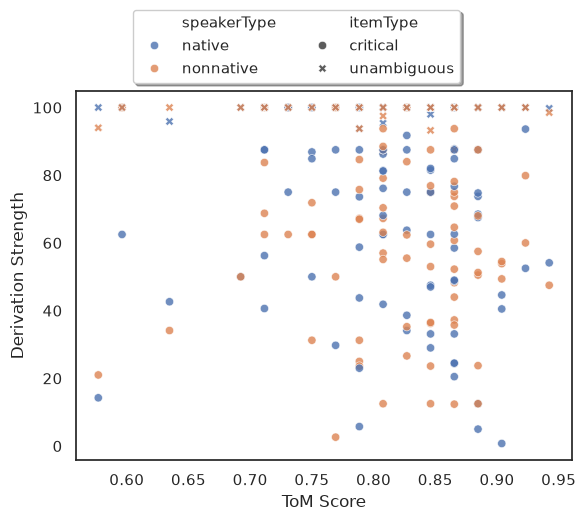

In [171]:
indivs = final_tom_df.groupby(["participantId", "itemType", "speakerType"])
indivs_means = indivs[["derivationStrength", "nathan_score_full"]].mean().reset_index()

sns.set(font_scale=1)
sns.set_theme(style='white')
ax = sns.scatterplot(
    data=indivs_means, x="nathan_score_full", y="derivationStrength", hue="speakerType", style="itemType",
    alpha=.8
)

ax.legend(
    loc='lower left', 
      bbox_to_anchor=(.1, 1),
      ncol=2, fancybox=True, shadow=True
)

ax.set(
    ylabel="Derivation Strength",
    xlabel="ToM Score"
)

In [185]:
sns.set(font_scale=1)
sns.set_theme(style='whitegrid')

ax = sns.scatterplot(
    data=indivs_merged, x="nathan_score_fullNative", y="natNonNatDiff", hue="itemType",
    alpha=.8
)

ax.legend(
    loc='lower left', 
      bbox_to_anchor=(.2, 1),
      ncol=2, fancybox=True, shadow=True
)

ax.set(
    ylabel="Derivation Strength Difference",
    xlabel="ToM Score"
)

plt.savefig(f"./dataPlots/tomVsDerivation.png")
plt.clf()

<Figure size 640x480 with 0 Axes>

In [253]:
indivs_means

,participantId,itemType,speakerType,derivationStrength,nathan_score_full
0,62c5f85ccf34c8d9c0650f6e,critical,native,24.375,0.865385
1,62c5f85ccf34c8d9c0650f6e,critical,nonnative,73.750,0.865385
2,62c5f85ccf34c8d9c0650f6e,unambiguous,native,100.000,0.865385
3,62c5f85ccf34c8d9c0650f6e,unambiguous,nonnative,100.000,0.865385
4,65465c5bc5a014ec683d55cf,critical,native,56.250,0.711538
...,...,...,...,...,...
299,6a2589e7b0645f2f7f1cc52c,unambiguous,nonnative,100.000,0.711538
300,6a3607f677860830aca5bdeb,critical,native,75.000,0.769231
301,6a3607f677860830aca5bdeb,critical,nonnative,100.000,0.769231
302,6a3607f677860830aca5bdeb,unambiguous,native,100.000,0.769231


In [222]:
sns.set(font_scale=1)
sns.set_theme(style='whitegrid')

indivs_merged["absDiff"] = abs(indivs_merged["natNonNatDiff"])
only_positive = indivs_merged[(indivs_merged["natNonNatDiff"] >= 0) & (indivs_merged["itemType"] == "critical")]

ax = sns.lmplot(
    data=only_positive, x="nathan_score_fullNative", y="absDiff",
)

# ax.legend(
#     loc='lower left', 
#     bbox_to_anchor=(.2, 1),
#     ncol=2, fancybox=True, shadow=True
# )

ax.set(
    ylabel="Derivation Strength Difference",
    xlabel="ToM Score"
)

plt.savefig(f"./dataPlots/tomCriticalOnly.png")
plt.clf()

<Figure size 500x500 with 0 Axes>

In [226]:
from scipy.stats import pearsonr

r_score = pearsonr(indivs_merged["absDiff"], indivs_merged["nathan_score_fullNative"])
print(r_score)

PearsonRResult(statistic=np.float64(-0.23743230524914113), pvalue=np.float64(0.11630448577945597))


### ToM Performance on just the Faces Items

In [263]:
# TODO

### Male vs Female Data

In [238]:
demographics = pd.read_csv("./dataRaw/demographics.csv")

male_ids = demographics[demographics["Sex"] == "Male"]["Participant id"].unique()
female_ids = demographics[demographics["Sex"] != "Male"]["Participant id"].unique()

crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]
crit_grouped = crit_only.groupby(["participantId", "speakerType"])["derivationStrength"].mean().reset_index()

critical_male = crit_grouped[crit_grouped["participantId"].isin(male_ids)]
critical_male["Gender"] = "Male"
critical_female = crit_grouped[crit_grouped["participantId"].isin(female_ids)]
critical_female["Gender"] = "Female"

gender_deriv = pd.concat([critical_male, critical_female])

ax = sns.barplot(
    data=gender_deriv,
    x="Gender", y="derivationStrength",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.8
)

ax.set(
    ylabel="Derivation Strength",
)

ax.legend(
    loc='lower left', 
    title='Speaker Type',
    bbox_to_anchor=(1, .5),
    fancybox=True, shadow=True
)

plt.savefig(f"./dataPlots/genderDerivation.png", bbox_inches='tight')
plt.clf()

<Figure size 640x480 with 0 Axes>

In [259]:
partDerivDiff

,newId,participantId,derivationStrengthNative,derivationStrengthNonNative,natNonNatDiff,Positive
31,1,69f0438cc141b27ed949788e,87.500,12.50,75.000,True
24,2,69cc1fac2b52b1c4dd21cc7d,87.500,25.00,62.500,True
55,3,6a0f1056788a67850f057de4,87.500,50.00,37.500,True
37,4,69fb86296fb6f0919bf31075,100.000,62.50,37.500,True
70,5,6a1cb95bf369926ac77ea9e5,100.000,62.50,37.500,True
...,...,...,...,...,...,...
15,72,69a8cff018bead25e4a5d848,62.500,100.00,-37.500,False
64,73,6a15d5fb80117206e7200cf7,40.625,83.75,-43.125,False
73,74,6a2222ff6e1036656b0d5d08,23.000,67.00,-44.000,False
0,75,62c5f85ccf34c8d9c0650f6e,24.375,73.75,-49.375,False


In [261]:
male_participants = gender_deriv[gender_deriv["Gender"] == "Male"]["participantId"].unique()
female_participants = gender_deriv[gender_deriv["Gender"] == "Female"]["participantId"].unique()

effect_participants = only_positive[only_positive["natNonNatDiff"] > 0]["participantId"].unique()

transcript = pd.read_csv("./dataOutput/audioTranscriptFiltered.csv")
effect_transcripts = transcript[transcript["participant"].isin(effect_participants)]

df = effect_transcripts.merge(
    partDerivDiff[["participantId", "derivationStrengthNative", "derivationStrengthNonNative"]],
    left_on="participant", 
    right_on="participantId",
)
df.to_csv("./dataOutput/audioTranscriptEffectOnly.csv", index=False)

### By Speaker

In [231]:
crit_only.columns

Index(['participantId', 'itemId', 'itemType', 'weak', 'strong', 'antonym',
       'lowfreq1', 'lowfreq2', 'derivationStrength', 'strongRating',
       'antonymRating', 'speakerType', 'speakerGender', 'trialid', 'weakRank',
       'weakFreq', 'strongRank', 'strongFreq', 'antonymRank', 'antonymFreq',
       'freqRatio', 'workerid', 'nathan_score_full'],
      dtype='str')

In [236]:
crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]
crit_grouped = crit_only.groupby(["participantId", "speakerType", "speakerGender"])["derivationStrength"].mean().reset_index()

ax = sns.barplot(
    data=crit_grouped,
    x="speakerType", y="derivationStrength",
    hue="speakerGender",
    errorbar="se", 
    palette="dark",
    alpha=.8
)

ax.set(
    ylabel="Derivation Strength",
)

ax.legend(
    loc='lower left', 
    title='Speaker Type',
    bbox_to_anchor=(1, .5),
    fancybox=True, shadow=True
)

plt.savefig(f"./dataPlots/speakerDerivation.png", bbox_inches='tight')
plt.clf()

<Figure size 640x480 with 0 Axes>

### By Age

In [34]:
partDerivDiff

,participantId,derivationStrengthNative,derivationStrengthNonNative,natNonNatDiff
0,62c5f85ccf34c8d9c0650f6e,24.375,73.750,-49.375
1,65465c5bc5a014ec683d55cf,56.250,68.750,-12.500
2,661c09a749790db73f8faba5,41.875,57.000,-15.125
3,66315563a848526fcfa7555b,73.625,84.625,-11.000
4,665795d82a087799023aaf0e,12.500,12.500,0.000
...,...,...,...,...
71,6a1de36b3f5c6160ff6bf6a4,5.000,23.750,-18.750
72,6a1f832105dd8c89b5e930ad,100.000,75.750,24.250
73,6a2222ff6e1036656b0d5d08,23.000,67.000,-44.000
74,6a2589e7b0645f2f7f1cc52c,87.500,62.500,25.000


PearsonRResult(statistic=np.float64(0.08603298253041183), pvalue=np.float64(0.459931522150281))

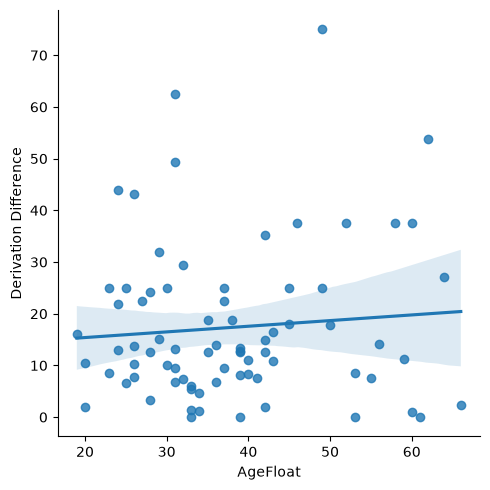

In [55]:
demographics = pd.read_csv("./dataRaw/demographics.csv")
crit_only = final_tom_df[final_tom_df["itemType"] == "critical"]

native_derivation = crit_only[
    crit_only["speakerType"] == "native"
].groupby(["participantId"])["derivationStrength"].mean()
nonnative_derivation = crit_only[
    crit_only["speakerType"] != "native"
].groupby(["participantId"])["derivationStrength"].mean()
partDerivDiff = pd.DataFrame(native_derivation).merge(
    pd.DataFrame(nonnative_derivation), 
    on="participantId", 
    suffixes=('Native', 'NonNative')
).reset_index()

partDerivDiff["natNonNatDiff"] = partDerivDiff["derivationStrengthNative"] - partDerivDiff["derivationStrengthNonNative"]
partDerivDiff["absDiff"] = abs(partDerivDiff["natNonNatDiff"])

age_deriv = partDerivDiff.merge(
    demographics[["Participant id", "Age"]],
    left_on="participantId",
    right_on="Participant id"
)

age_deriv["AgeFloat"] = age_deriv["Age"].astype(float)

ax = sns.lmplot(
    data=age_deriv,
    x="AgeFloat", y="absDiff"
)

ax.set(
    ylabel="Derivation Difference",
)

r_val = pearsonr(age_deriv["AgeFloat"], age_deriv["absDiff"])
r_val
# We find no evidence that age has an effect in our experiment, counter to antoniou2016only

# EXPLORATORY

In [228]:
crit_only[crit_only["participantId"] == "62c5f85ccf34c8d9c0650f6e"]

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,antonymRating,speakerType,speakerGender,trialid,freqRatio,workerid,nathan_score_full,derivationDiff,meanDeriv
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,0.0,nonnative,male,21,1.767265,62c5f85ccf34c8d9c0650f6e,0.865385,80.0,-1.875
76,62c5f85ccf34c8d9c0650f6e,2,critical,good,excellent,bad,dramatic,technical,90.0,10.0,0.0,native,male,32,1.342306,62c5f85ccf34c8d9c0650f6e,0.865385,80.0,-1.875
152,62c5f85ccf34c8d9c0650f6e,3,critical,funny,hilarious,boring,resilient,erratic,65.0,35.0,0.0,nonnative,female,15,1.192338,62c5f85ccf34c8d9c0650f6e,0.865385,30.0,-1.875
228,62c5f85ccf34c8d9c0650f6e,4,critical,cold,freezing,hot,fictional,communal,80.0,20.0,0.0,nonnative,male,20,1.141147,62c5f85ccf34c8d9c0650f6e,0.865385,60.0,-1.875
304,62c5f85ccf34c8d9c0650f6e,5,critical,big,enormous,tiny,rural,creative,15.0,85.0,0.0,native,male,28,1.113758,62c5f85ccf34c8d9c0650f6e,0.865385,-70.0,-1.875
380,62c5f85ccf34c8d9c0650f6e,6,critical,old,ancient,new,illegal,crazy,75.0,25.0,0.0,nonnative,female,10,1.076913,62c5f85ccf34c8d9c0650f6e,0.865385,50.0,-1.875
456,62c5f85ccf34c8d9c0650f6e,7,critical,large,gigantic,little,scattered,incapable,10.0,90.0,0.0,native,male,27,1.885286,62c5f85ccf34c8d9c0650f6e,0.865385,-80.0,-1.875
532,62c5f85ccf34c8d9c0650f6e,8,critical,wet,drenched,dry,ephemeral,rudimentary,50.0,50.0,0.0,nonnative,female,16,1.542919,62c5f85ccf34c8d9c0650f6e,0.865385,0.0,-1.875
608,62c5f85ccf34c8d9c0650f6e,9,critical,happy,ecstatic,sad,anecdotal,extravagant,60.0,40.0,0.0,nonnative,female,11,1.585154,62c5f85ccf34c8d9c0650f6e,0.865385,20.0,-1.875
684,62c5f85ccf34c8d9c0650f6e,10,critical,hot,scalding,cold,orchestral,gaunt,5.0,95.0,0.0,native,female,2,2.135141,62c5f85ccf34c8d9c0650f6e,0.865385,-90.0,-1.875


In [ ]:
df[df["workerid"] == "699e4bcadd64768ae7feedad"]